In [ ]:
from pathlib import Path # For handling file paths
import pandas as pd # For data manipulation and analysis

file_path = r'C:\Users\Admin\Team_ML10\Jesse\bank-additional\bank-additional-full.csv' # Update this path to where you have the data file

# Load the data FIRST
data = pd.read_csv(file_path, sep=';')

# Now inspect it
print('base directory is', Path.cwd()) # Print the current working directory to confirm where the script is running
print(data.dtypes) # Print the data types of each column to understand the structure of the DataFrame
print(data.count()) # Print the count of non-null values in each column to check for missing data

data.head() # Display the first few rows of the DataFrame to understand its structure and contents

base directory is c:\Users\Admin\Team_ML10\Jesse\Code
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object
age               41188
job               41188
marital           41188
education         41188
default           41188
housing           41188
loan              41188
contact           41188
month             41188
day_of_week       41188
duration          41188
campaign          41188
pdays             41188
previous          41188
poutcome          41188
emp.var.rate      41188
co

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
# Create a summary DataFrame to show non-null counts, unique values, and missing values for each column
summary = pd.DataFrame({
    'non_null_count': data.count(),
    'unique_values': data.nunique(),
    'missing_values': data.isnull().sum()
})

print(summary)

                non_null_count  unique_values  missing_values
age                      41188             78               0
job                      41188             12               0
marital                  41188              4               0
education                41188              8               0
default                  41188              3               0
housing                  41188              3               0
loan                     41188              3               0
contact                  41188              2               0
month                    41188             10               0
day_of_week              41188              5               0
duration                 41188           1544               0
campaign                 41188             42               0
pdays                    41188             27               0
previous                 41188              8               0
poutcome                 41188              3               0
emp.var.

In [20]:

# Load data
file_path = r'C:\Users\Admin\Team_ML10\Jesse\bank-additional\bank-additional-full.csv'
data = pd.read_csv(file_path, sep=';')

# Split features/target
X = data.drop(columns=['y'])
y = data['y']

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols), # One-hot encode categorical features, ignoring unknown categories in test data
        ('num', 'passthrough', numeric_cols) # Pass through numeric features without transformation
    ]
)

# Model
model = RandomForestClassifier(n_estimators=300, random_state=42)

# Pipeline
pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', model)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit
pipe.fit(X_train, y_train)

# Extract feature names after one-hot encoding
ohe = pipe.named_steps['preprocess'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_cols)
all_features = np.concatenate([ohe_features, numeric_cols])

# Extract importances
importances = pipe.named_steps['model'].feature_importances_

# Rank
feature_ranking = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_ranking.head(20))


C:\Users\Admin\AppData\Local\Temp\ipykernel_28144\201700065.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


                        feature  importance
54                     duration    0.276603
61                    euribor3m    0.093781
53                          age    0.079251
62                  nr.employed    0.047026
55                     campaign    0.040159
56                        pdays    0.030477
60                cons.conf.idx    0.026566
59               cons.price.idx    0.023711
52             poutcome_success    0.022652
58                 emp.var.rate    0.020731
29                  housing_yes    0.013418
27                   housing_no    0.013205
0                    job_admin.    0.012085
22  education_university.degree    0.011869
13              marital_married    0.011682
46              day_of_week_mon    0.011530
57                     previous    0.011396
19        education_high.school    0.011228
47              day_of_week_thu    0.010920
49              day_of_week_wed    0.010820


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline with class weighting
pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])

pipe.fit(X_train, y_train)

# Evaluate
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.91      0.97      0.94      7310
         yes       0.56      0.29      0.38       928

    accuracy                           0.89      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.88      0.89      0.88      8238

[[7103  207]
 [ 660  268]]


Accuracy: 0.8947560087399854

Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.97      0.94      7310
         yes       0.56      0.29      0.38       928

    accuracy                           0.89      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.88      0.89      0.88      8238



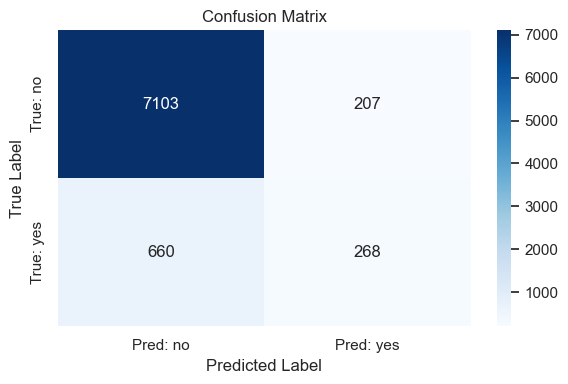

In [37]:
# Predict
y_pred = pipe.predict(X_test)

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['no', 'yes'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: no', 'Pred: yes'],
            yticklabels=['True: no', 'True: yes'])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Load data
file_path = r'C:\Users\Admin\Team_ML10\Jesse\bank-additional\bank-additional-full.csv'
data = pd.read_csv(file_path, sep=';')

# define columns to drop
cols_to_drop = ['day_of_week', 'duration']

# define remaining columns explicitly
remaining_cols = [col for col in data.columns if col not in cols_to_drop]

# use the cleaned data everywhere
data_clean = data[remaining_cols]

# Split features/target
X = data_clean.drop(columns=['y'])
y = data_clean['y']

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

# Model
model = RandomForestClassifier(n_estimators=300, random_state=42)

# Pipeline
pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', model)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit
pipe.fit(X_train, y_train)

# Extract feature names after one-hot encoding
ohe = pipe.named_steps['preprocess'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_cols)
all_features = np.concatenate([ohe_features, numeric_cols])

# Extract importances
importances = pipe.named_steps['model'].feature_importances_

# Rank
feature_ranking = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_ranking.head(20))

C:\Users\Admin\AppData\Local\Temp\ipykernel_28144\1559345081.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


                        feature  importance
48                          age    0.184088
55                    euribor3m    0.160459
49                     campaign    0.090369
56                  nr.employed    0.052562
50                        pdays    0.035357
54                cons.conf.idx    0.025594
52                 emp.var.rate    0.023808
53               cons.price.idx    0.021765
47             poutcome_success    0.020593
27                   housing_no    0.019196
29                  housing_yes    0.019117
0                    job_admin.    0.017785
22  education_university.degree    0.016436
19        education_high.school    0.016386
13              marital_married    0.016230
51                     previous    0.014850
14               marital_single    0.014660
9                job_technician    0.014334
30                      loan_no    0.013892
32                     loan_yes    0.013551


Accuracy: 0.8970623937848993

Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7310
         yes       0.58      0.31      0.40       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238



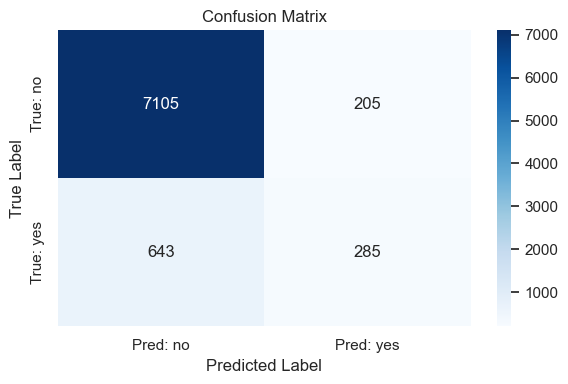

In [33]:
# Predict
y_pred = pipe.predict(X_test)

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['no', 'yes'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: no', 'Pred: yes'],
            yticklabels=['True: no', 'True: yes'])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

Although the model achieves a high overall accuracy of 89.7%, this metric is misleading due to class imbalance. The model performs very well on the majority class (“no”), with a recall of 97%, but struggles to identify the minority class (“yes”), achieving only 31% recall. This means the model misses most customers who would actually subscribe, which limits its usefulness for targeted marketing. Improving performance on the positive class requires class balancing techniques, model tuning, or alternative algorithms.

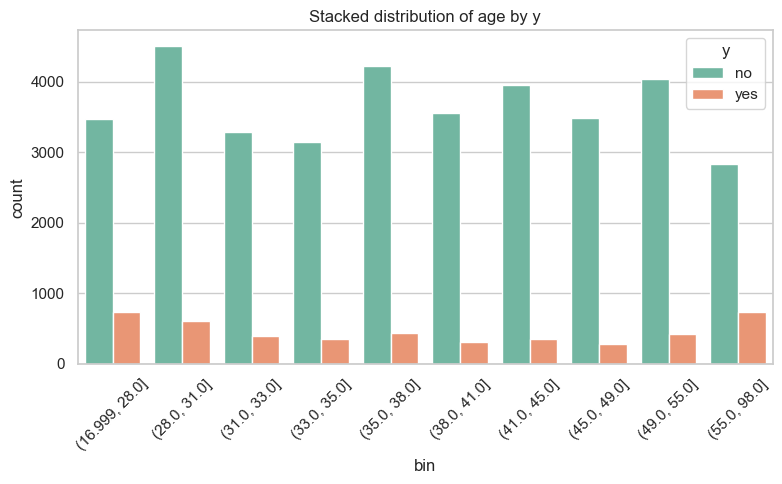

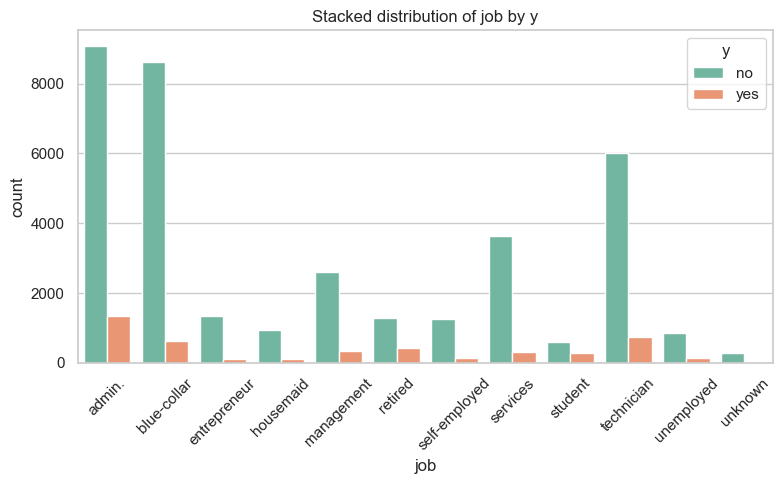

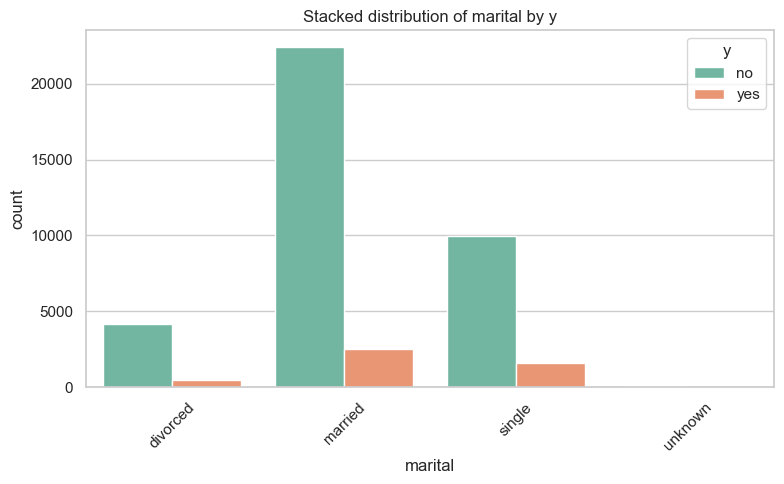

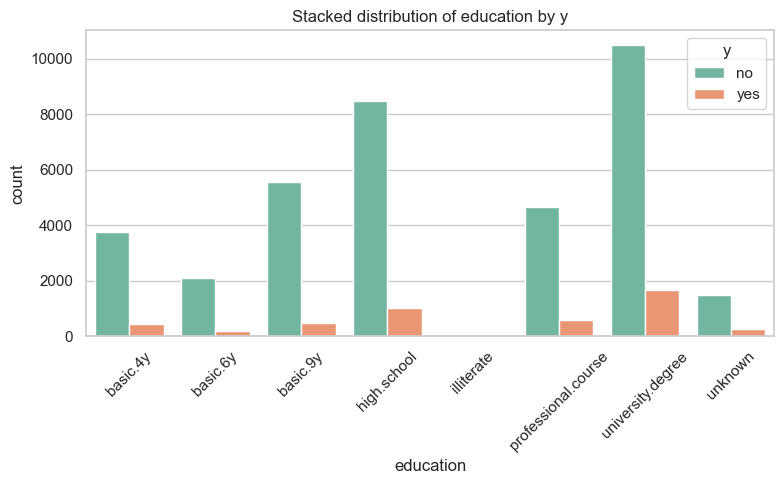

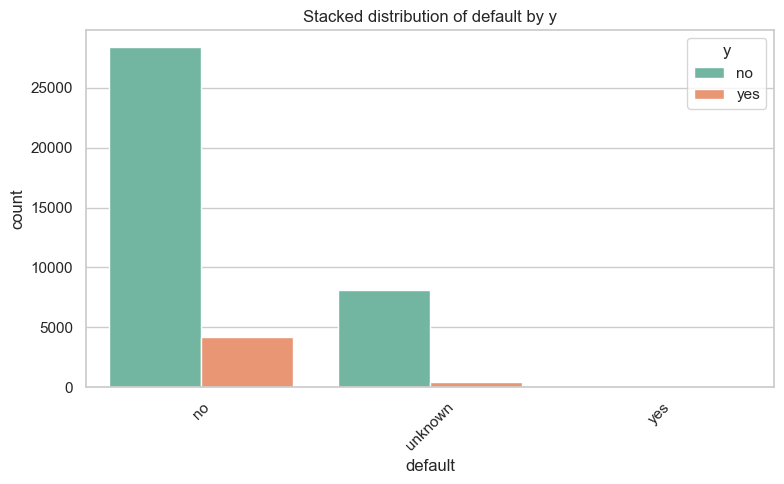

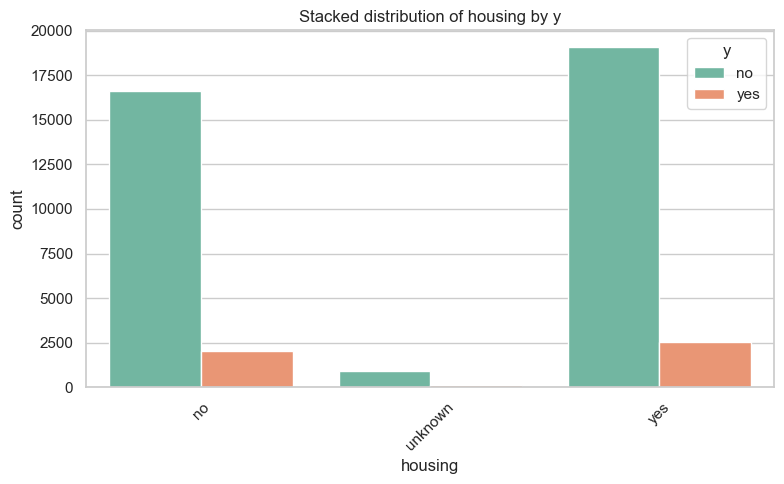

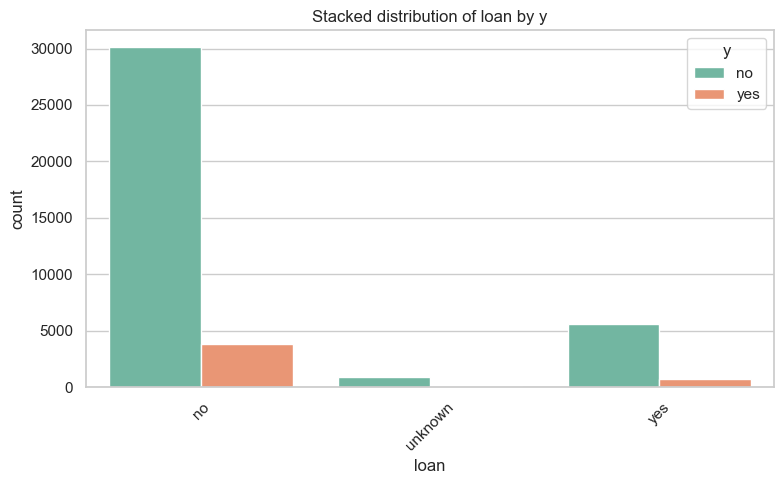

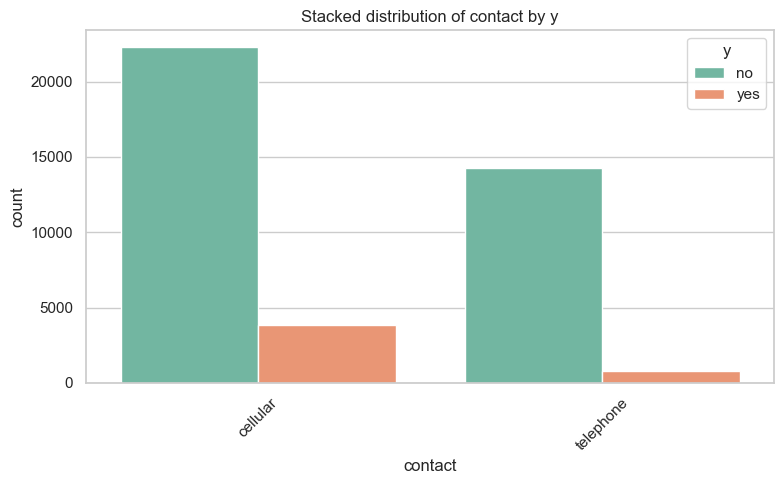

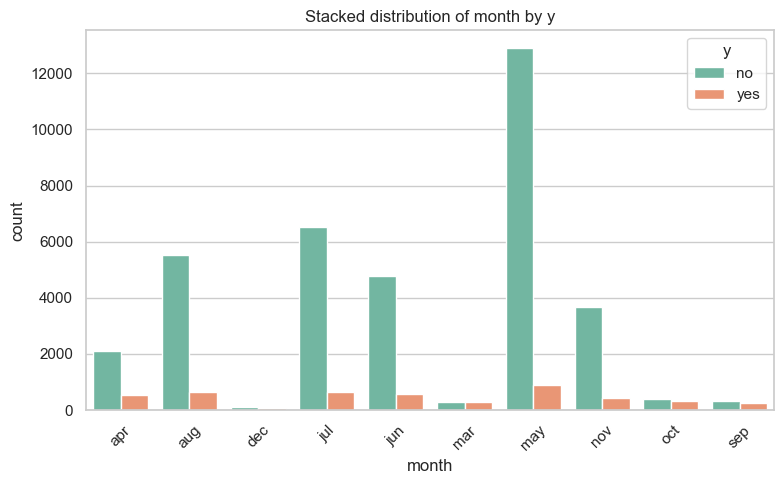

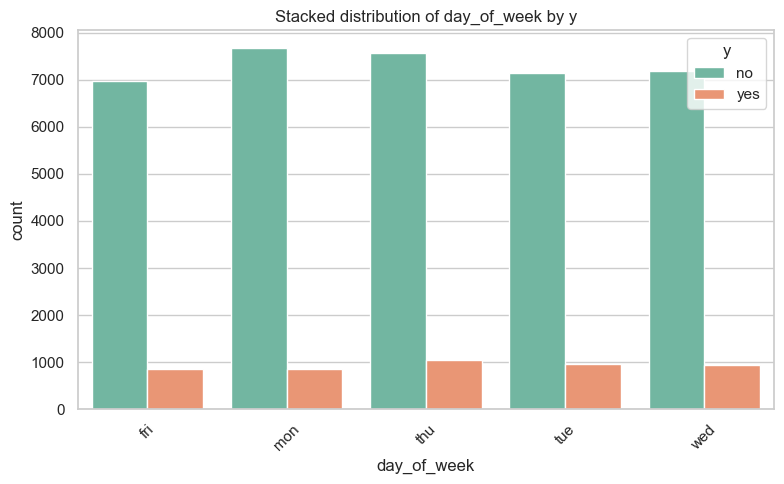

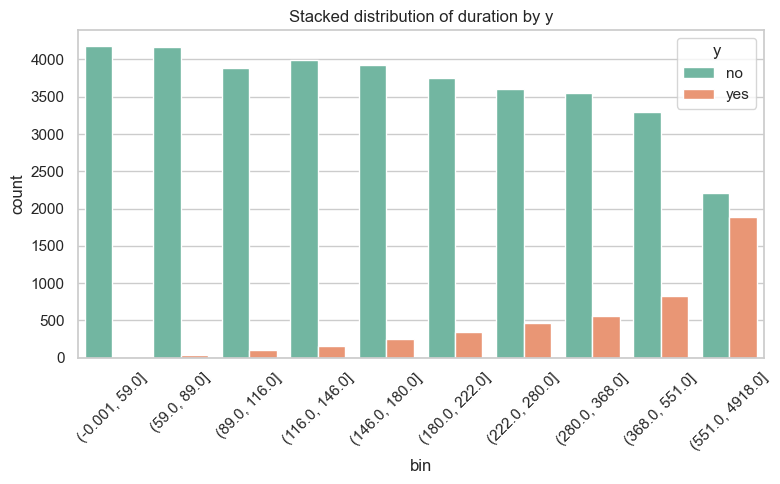

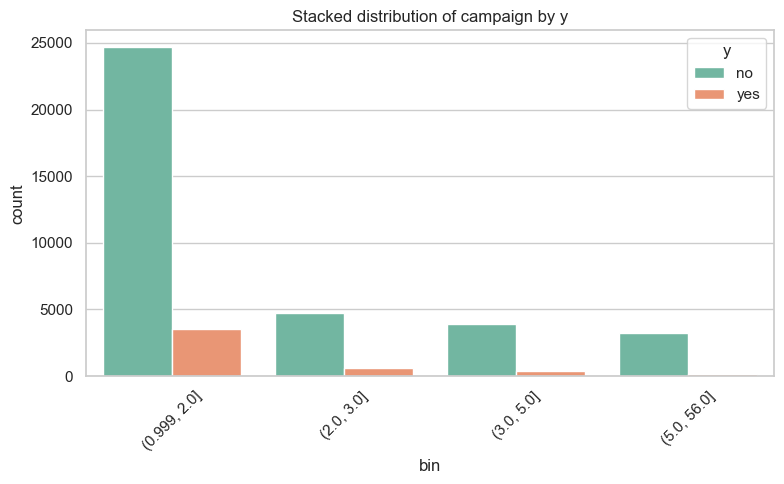

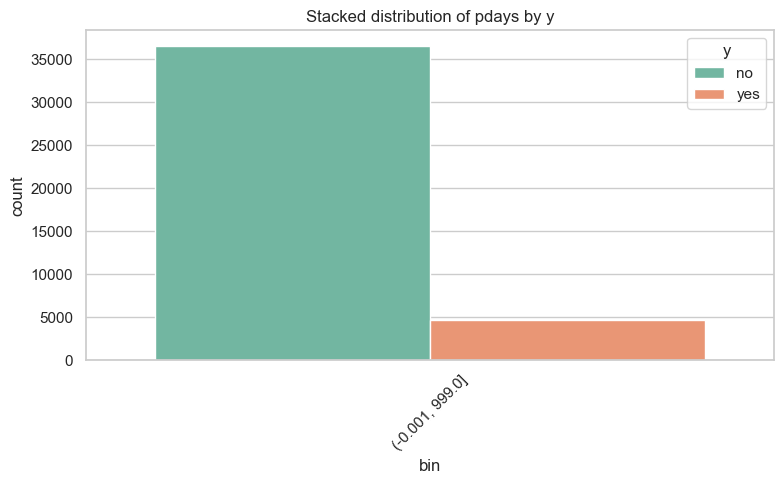

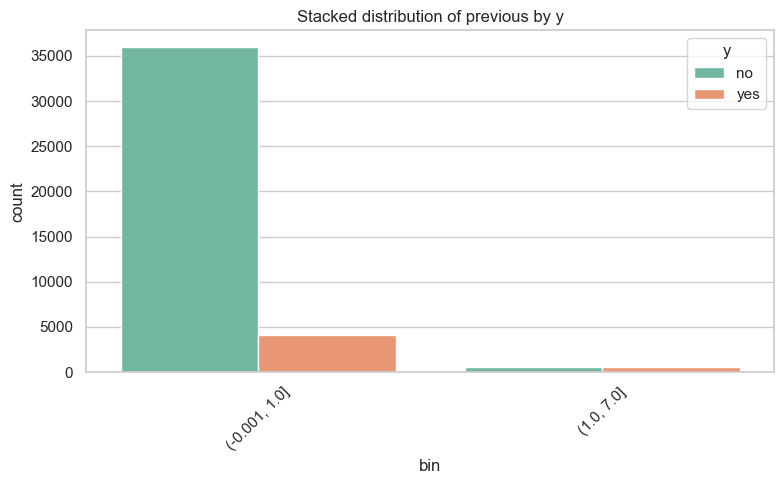

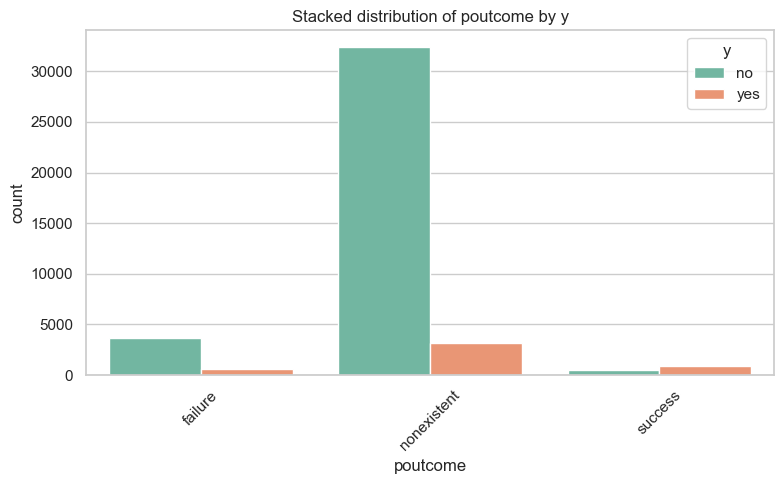

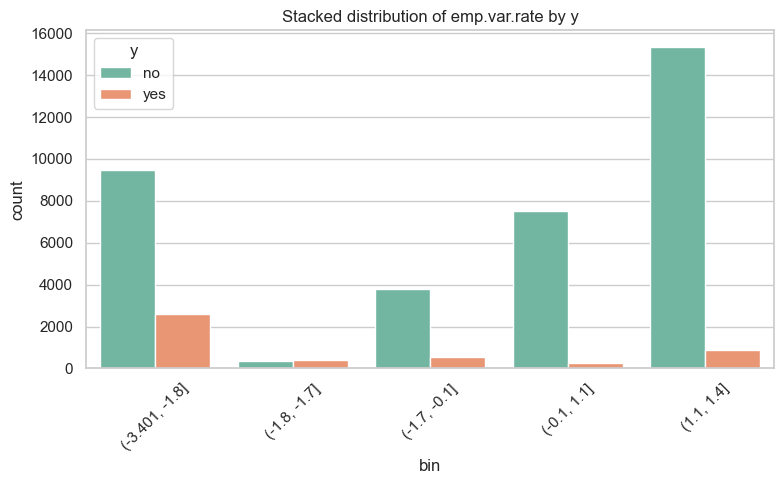

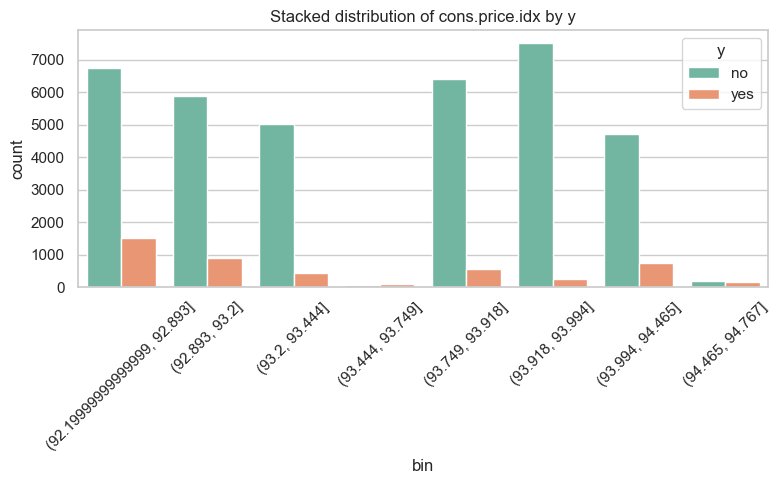

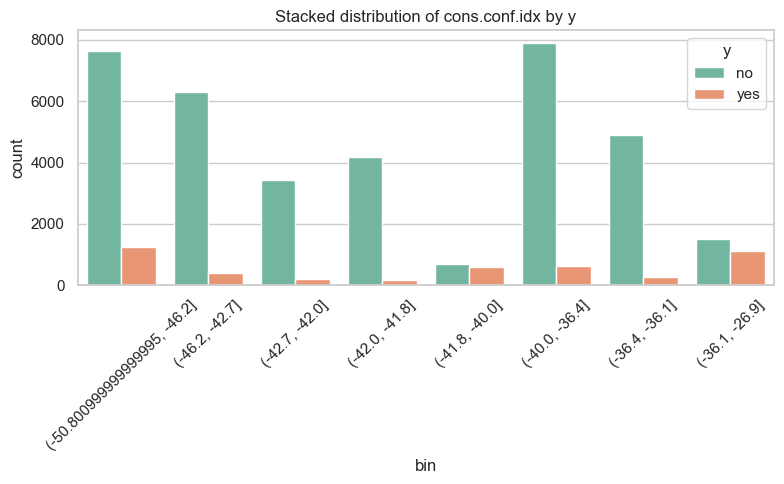

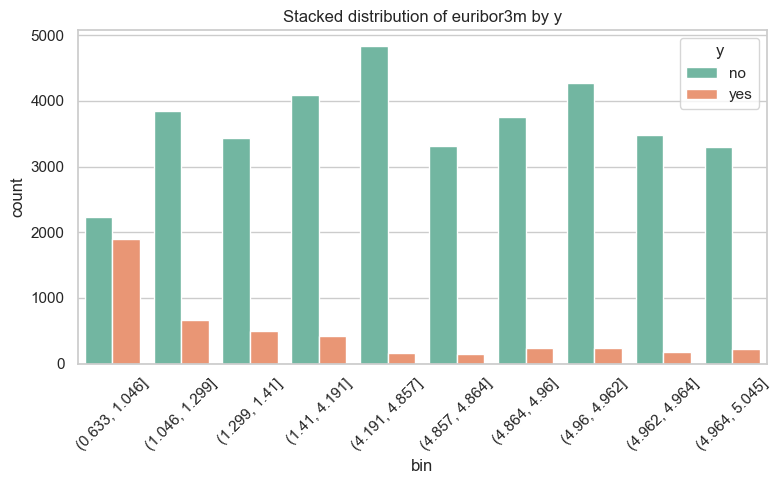

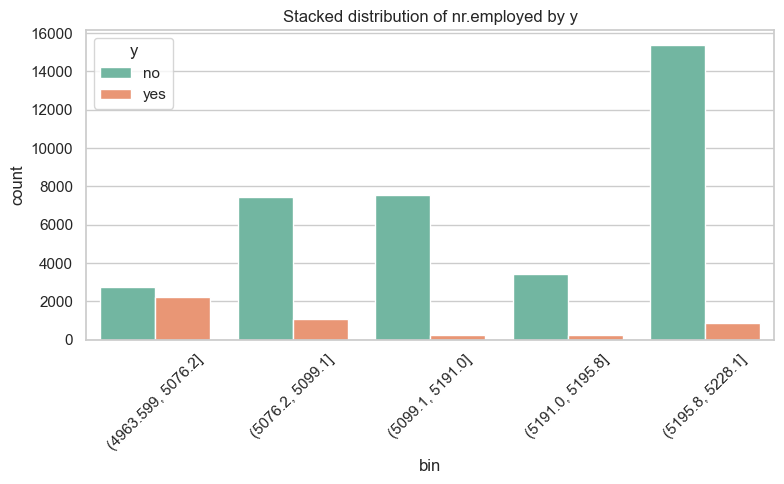

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

target = "y"
features = [col for col in data.columns if col != target]

for col in features:
    plt.figure(figsize=(8, 5))

    if pd.api.types.is_numeric_dtype(data[col]):
        # Bin numeric columns
        df_plot = data.copy()
        df_plot["bin"] = pd.qcut(df_plot[col], q=10, duplicates="drop")

        # Aggregate counts
        plot_data = df_plot.groupby(["bin", target]).size().reset_index(name="count")

        # Use barplot instead of histplot
        sns.barplot(
            data=plot_data,
            x="bin",
            y="count",
            hue=target,
            palette="Set2"
        )
        plt.xticks(rotation=45)
        plt.title(f"Stacked distribution of {col} by {target}")

    else:
        # Categorical columns
        plot_data = data.groupby([col, target]).size().reset_index(name="count")

        sns.barplot(
            data=plot_data,
            x=col,
            y="count",
            hue=target,
            palette="Set2"
        )
        plt.xticks(rotation=45)
        plt.title(f"Stacked distribution of {col} by {target}")

    plt.tight_layout()
    plt.show()